# Projet Python

## Introduction

Le projet Python consiste à mettre en pratique les compétences acquises en Python pour développer une démarche de machine learning appliquée à un problème concret. 

Nous nous intéressons ici à la production d’électricité par filière et coûts de production au pas horaire en France ([data - gouv](https://www.data.gouv.fr/fr/datasets/production-delectricite-par-filiere-et-couts-de-production-au-pas-horaire/))

## Données

Chaque mois, les informations relatives à la production d'électricité par filière sont établies à partir de données de comptage, de télémesures ainsi que des estimations.

Les informations relatives au coût constaté de production concernent une moyenne de l’ensemble des moyens de production (toutes filières confondues).
Cette information est différente du coût marginal horaire du système, qui correspondrait en première approche au coût variable du moyen _dispatchable le plus cher démarré_. Ces coûts ne sont donc en particulier pas comparables aux coûts marginaux prospectifs publiés par la CRE.

## Enoncé

1. Lire les données (attention aux séparateurs de colonnes et de décimales)

2. Sélectionner uniquement les colonnes pertinentes:
    - Territoire
    - Statut
    - Date
    - Solaire photovoltaïque (MW)
  - Renommer les colonnes avec des noms ""pythonic"" (ex: ""Solaire photovoltaïque (MW)"" devient ""solaire_photovoltaique_mw"")

3. Transformer la colonne date en datetime

4. Décrire les données: 
   - Nombre de lignes et de colonnes
   - Types de données
   - Valeurs manquantes
   - Statistiques descriptives
   - Combien y'a-t-il de données validées et estimées?

5. Nettoyer les données:
    - Conserver uniquement les données validées
    - Supprimer les lignes avec des valeurs manquantes
    - Convertir les énergies négatives en 0
  
6. Visualiser les données:
    - Tracer l'évolution de la production d'électricité par filière au cours du temps
    - Tracer les 300 premières valeurs de production d'électricité par filière
  
On observe que la **production d'électricité solaire est saisonnière**

Lorsqu'une variable est saisonnaière, il est intéressant d'ajouter des variables calendaires e.g. qui capturent la saisonnalité dans le processus de feature engineering.

7. Feature engineering:
    - **Création de nouvelles variables à partir de la colonne ""date""**:
       - Créer une nouvelle colonne ""jour_semaine"" qui contient le jour de la semaine (0=dimanche, 1=lundi, ..., 6=samedi)
       - Créer une nouvelle colonne ""mois"" qui contient le mois (1=janvier, 2=février, ..., 12=décembre)
       - Créer une nouvelle colonne ""heure"" qui contient l'heure (0=00h, 1=01h, ..., 23=23h)
   - Ajout de données externes



In [51]:
import pandas as pd

df = pd.read_csv(
    "data/train_production_electricite_par_filiere.csv",
    sep=";",
)

In [52]:
df.head()

,Territoire,Statut,Date,Production totale (MW),Thermique (MW),Bagasse/charbon (MW),Hydraulique (MW),Micro-hydraulique (MW),Solaire photovoltaïque (MW),Eolien (MW),Bioénergies (MW),Géothermie (MW),Importations (MW),Coût moyen de production (€/MWh)
0,Réunion,Validé,2019-01-01 00:00:00+00:00,299.21,62.21,168.59,66.67,NaN,-0.43,0.47,1.70,NaN,NaN,194.044288
1,Martinique,Validé,2019-01-01 00:00:00+00:00,131.87,95.24,NaN,0.00,NaN,-0.09,6.51,30.21,NaN,NaN,295.968713
2,Guadeloupe,Validé,2019-01-01 00:00:00+00:00,152.19,86.03,40.70,5.38,NaN,-0.10,4.22,2.11,13.84,NaN,244.842654
3,Guyane,Validé,2019-01-01 00:00:00+00:00,84.77,40.18,NaN,43.98,NaN,0.00,NaN,0.61,NaN,NaN,305.721167
4,Guyane,Validé,2019-01-01 01:00:00+00:00,82.43,39.68,NaN,42.21,NaN,0.00,NaN,0.54,NaN,NaN,308.024401


In [53]:
df = df[["Territoire", "Statut", "Date", "Solaire photovoltaïque (MW)"]]

df = df.rename(
    columns={
        "Territoire": "territoire",
        "Statut": "statut",
        "Date": "date",
        "Solaire photovoltaïque (MW)": "solaire_photovoltaique_mw",
    }
)

df["date"] = pd.to_datetime(df["date"])

In [54]:
df.head()

,territoire,statut,date,solaire_photovoltaique_mw
0,Réunion,Validé,2019-01-01 00:00:00+00:00,-0.43
1,Martinique,Validé,2019-01-01 00:00:00+00:00,-0.09
2,Guadeloupe,Validé,2019-01-01 00:00:00+00:00,-0.10
3,Guyane,Validé,2019-01-01 00:00:00+00:00,0.00
4,Guyane,Validé,2019-01-01 01:00:00+00:00,0.00


In [55]:
# Description du jeu de données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34752 entries, 0 to 34751
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   territoire                 34752 non-null  object             
 1   statut                     34752 non-null  object             
 2   date                       34752 non-null  datetime64[ns, UTC]
 3   solaire_photovoltaique_mw  34752 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 1.1+ MB


In [56]:
df.describe()

,solaire_photovoltaique_mw
count,34752.000000
mean,13.947148
std,23.673597
min,-1.680000
25%,-0.110000
50%,1.020000
75%,20.120000
max,126.750000


In [57]:
# Nettoyage des données
df = df.dropna()

# Si valeur négative, on la remplace par 0
df.loc[df["solaire_photovoltaique_mw"] < 0, "solaire_photovoltaique_mw"] = 0

In [58]:
df = df[df["statut"] == "Validé"]

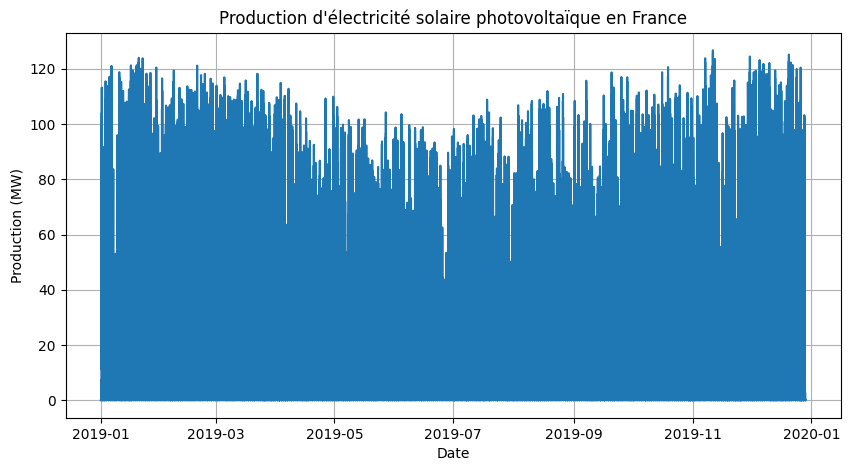

In [59]:
import matplotlib.pyplot as plt

# Visualisation des données
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["solaire_photovoltaique_mw"])
plt.title("Production d'électricité solaire photovoltaïque en France")
plt.xlabel("Date")
plt.ylabel("Production (MW)")
plt.grid()
plt.show()

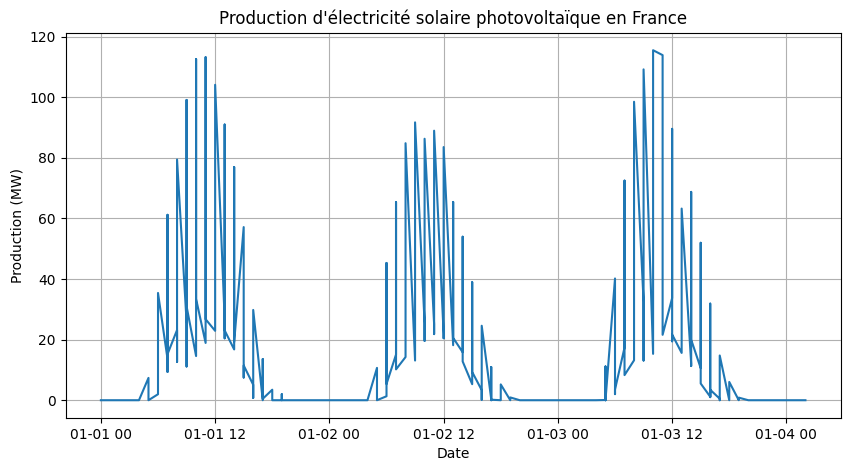

In [60]:
# Visualisation des données
plt.figure(figsize=(10, 5))
plt.plot(df.iloc[:300]["date"], df.iloc[:300]["solaire_photovoltaique_mw"])
plt.title("Production d'électricité solaire photovoltaïque en France")
plt.xlabel("Date")
plt.ylabel("Production (MW)")
plt.grid()
plt.show()

In [61]:
# Feature engineering
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["hour"] = df["date"].dt.hour

In [62]:
df.head()

,territoire,statut,date,solaire_photovoltaique_mw,month,day,day_of_week,hour
0,Réunion,Validé,2019-01-01 00:00:00+00:00,0.0,1,1,1,0
1,Martinique,Validé,2019-01-01 00:00:00+00:00,0.0,1,1,1,0
2,Guadeloupe,Validé,2019-01-01 00:00:00+00:00,0.0,1,1,1,0
3,Guyane,Validé,2019-01-01 00:00:00+00:00,0.0,1,1,1,0
4,Guyane,Validé,2019-01-01 01:00:00+00:00,0.0,1,1,1,1
